Memory Usage: 548.88 MB

image 1/1 c:\Users\joshu\Workspace\VisAssistGlasses\openvino\house.jpg: 640x448 1 chair, 90.8ms
Speed: 7.5ms preprocess, 90.8ms inference, 14.9ms postprocess per image at shape (1, 3, 640, 448)
chair: 0.82, bbox=[673.1286010742188, 763.0607299804688, 979.422607421875, 1323.72021484375]
Annotated image saved to detections.jpg


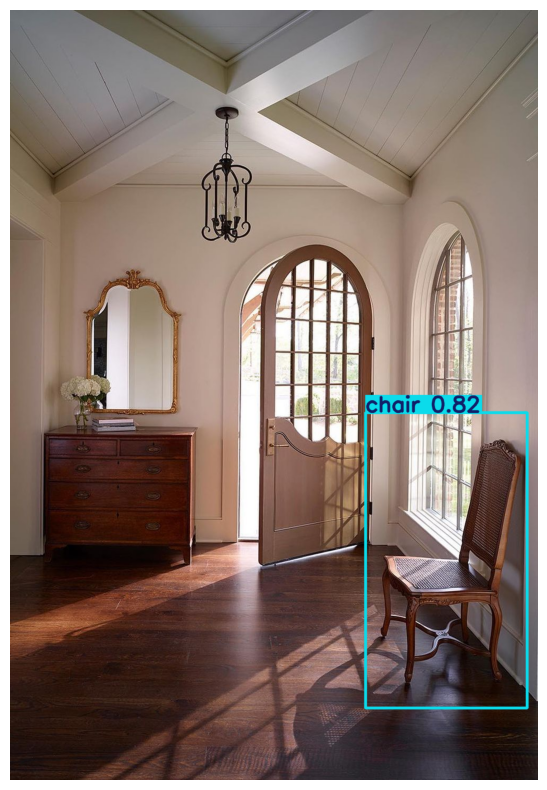

Memory Usage: 559.70 MB


In [13]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# --- CONFIG ---
MODEL_PATH = "best.pt"       # Path to your YOLOv8 weights
IMAGE_PATH = "house.jpg"      # Path to test image
OUTPUT_PATH = "detections.jpg"  # Where to save annotated image
# ----------------

import psutil
import os

# Get current process info
process = psutil.Process(os.getpid())

# Print memory usage in MB
print(f"Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")

# Load model
model = YOLO(MODEL_PATH)

# Run inference
results = model(IMAGE_PATH)

# Process and print detections
for r in results:
    boxes = r.boxes
    if len(boxes) == 0:
        print("No objects detected.")
    for box in boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
        class_name = model.names[cls_id]
        print(f"{class_name}: {conf:.2f}, bbox={xyxy}")

# Annotate image
annotated = results[0].plot()  # Returns image with boxes drawn

# Save annotated image
cv2.imwrite(OUTPUT_PATH, annotated)
print(f"Annotated image saved to {OUTPUT_PATH}")

# Display in notebook (optional)
try:
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.show()
except Exception as e:
    print(f"Could not display image inline: {e}")

# Print memory usage in MB
print(f"Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")



In [3]:
from ultralytics import YOLO

model = YOLO("best.pt")
model.export(format="onnx")  # exports to best.onnx


Ultralytics 8.3.155  Python-3.9.23 torch-2.7.1+cu126 CPU (13th Gen Intel Core(TM) i7-13700HX)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from 'best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (21.5 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success  1.0s, saved as 'best.onnx' (42.7 MB)

Export complete (1.4s)
Results saved to C:\Users\joshu\Workspace\VisAssistGlasses\openvino
Predict:         yolo predict task=detect model=best.onnx imgsz=640  
Validate:        yolo val task=detect model=best.onnx imgsz=640 data=./Indoor--1/data.yaml  
Visualize:       https://netron.app


'best.onnx'

Initial Memory Usage: 555.39 MB
Diagnosing model output format...
=== MODEL OUTPUT DIAGNOSIS ===
Model loaded: yolov8n_int8.xml
Input shape: [1,3,640,640]
Output shape: [1,14,8400]
Device: CPU
Raw output shape: (1, 14, 8400)
Raw output dtype: float32
Output without batch: (14, 8400)
Transposing output...
After transpose: (8400, 14)

Analyzing first 3 detections:
Detection 0:
  Length: 14
  First 8 values: [     5.6901      15.835      12.055      32.186  7.1746e-10  3.6464e-09  3.5489e-08  1.4531e-08]
  Max class score: 0.000 at index 5
  Class scores range: 0.000 to 0.000
Detection 1:
  Length: 14
  First 8 values: [     10.564      14.778      17.321      28.939  9.4316e-11  5.3844e-10  9.0512e-09    2.85e-09]
  Max class score: 0.000 at index 5
  Class scores range: 0.000 to 0.000
Detection 2:
  Length: 14
  First 8 values: [     16.707      15.242      22.142      30.273   9.203e-10  6.9946e-09  4.6388e-08  3.0717e-08]
  Max class score: 0.000 at index 5
  Class scores range: 0.000

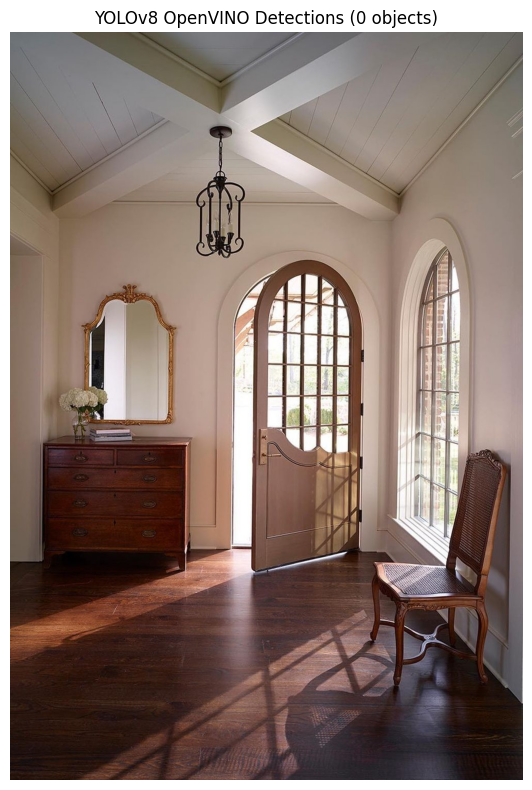

Final Memory Usage: 724.02 MB


In [14]:
import openvino as ov
import cv2
import numpy as np
import matplotlib.pyplot as plt
import psutil
import os
from pathlib import Path
from typing import List, Tuple, Dict

# --- CONFIG ---
MODEL_PATH = "yolov8n_int8.xml"    # Path to your OpenVINO model (.xml)
IMAGE_PATH = "house.jpg"           # Path to test image
OUTPUT_PATH = "detections_ov.jpg"  # Where to save annotated image
CONFIDENCE_THRESHOLD = 0.25        # Confidence threshold for detections
NMS_THRESHOLD = 0.45              # Non-maximum suppression threshold
INPUT_SIZE = (640, 640)           # Model input size
# ----------------

# COCO class names (default for YOLOv8)
CLASS_NAMES = ['bed', 'chair', 'door', 'door-frame', 'shower', 'sink', 'sofa', 'stairs', 'table', 'toilet']

# Colors for bounding boxes (BGR format)
COLORS = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255),
    (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0), (128, 0, 128), (0, 128, 128),
    (64, 0, 0), (0, 64, 0), (0, 0, 64), (64, 64, 0), (64, 0, 64), (0, 64, 64),
    (192, 0, 0), (0, 192, 0), (0, 0, 192), (192, 192, 0), (192, 0, 192), (0, 192, 192)
] * 10  # Repeat colors if needed


class YOLOv8OpenVINO:
    def __init__(self, model_path: str, device: str = "CPU"):
        """
        Initialize YOLOv8 OpenVINO inference
        
        Args:
            model_path: Path to OpenVINO model (.xml file)
            device: Target device (CPU, GPU, etc.)
        """
        self.model_path = model_path
        self.device = device
        
        # Load OpenVINO Core
        self.core = ov.Core()
        
        # Load model
        self.model = self.core.read_model(model_path)
        self.compiled_model = self.core.compile_model(self.model, device)
        
        # Get model info
        self.input_layer = self.compiled_model.input(0)
        self.output_layer = self.compiled_model.output(0)
        
        self.input_name = self.input_layer.any_name
        self.input_shape = self.input_layer.shape
        self.output_shape = self.output_layer.shape
        
        print(f"Model loaded: {model_path}")
        print(f"Input shape: {self.input_shape}")
        print(f"Output shape: {self.output_shape}")
        print(f"Device: {device}")
        
        # Model input size
        self.input_height = self.input_shape[2]
        self.input_width = self.input_shape[3]
        
        # Class names
        self.class_names = CLASS_NAMES
        self.num_classes = len(self.class_names)
    
    def preprocess_image(self, image: np.ndarray) -> Tuple[np.ndarray, float, Tuple[int, int]]:
        """
        Preprocess image for YOLOv8 inference
        
        Returns:
            preprocessed_image: Preprocessed image
            scale: Scaling factor used
            pad: Padding applied (pad_w, pad_h)
        """
        original_height, original_width = image.shape[:2]
        
        # Calculate scale to fit image in input size while maintaining aspect ratio
        scale = min(self.input_width / original_width, self.input_height / original_height)
        
        # Calculate new dimensions
        new_width = int(original_width * scale)
        new_height = int(original_height * scale)
        
        # Resize image
        resized = cv2.resize(image, (new_width, new_height))
        
        # Calculate padding
        pad_w = (self.input_width - new_width) // 2
        pad_h = (self.input_height - new_height) // 2
        
        # Pad image
        padded = np.pad(resized, 
                       ((pad_h, self.input_height - new_height - pad_h),
                        (pad_w, self.input_width - new_width - pad_w),
                        (0, 0)), 
                       mode='constant', constant_values=114)
        
        # Normalize and transpose
        normalized = padded.astype(np.float32) / 255.0
        transposed = np.transpose(normalized, (2, 0, 1))  # HWC to CHW
        batched = np.expand_dims(transposed, axis=0)  # Add batch dimension
        
        return batched, scale, (pad_w, pad_h)
    
    def postprocess_detections(self, outputs: np.ndarray, scale: float, pad: Tuple[int, int], 
                             original_shape: Tuple[int, int]) -> List[Dict]:
        """
        Postprocess YOLOv8 outputs to get bounding boxes, scores, and class IDs
        """
        pad_w, pad_h = pad
        original_height, original_width = original_shape
        
        # Debug: Print output shape for troubleshooting
        print(f"Debug - Output shape: {outputs.shape}")
        
        # YOLOv8 output format: [batch, 4 + num_classes, num_detections]
        # Where 4 = [x_center, y_center, width, height]
        outputs = outputs[0]  # Remove batch dimension
        
        # YOLOv8 typically outputs [84, 8400] where 84 = 4 bbox + 80 classes
        # We need to transpose to [8400, 84]
        if outputs.shape[0] < outputs.shape[1]:
            outputs = outputs.T
        
        print(f"Debug - After transpose: {outputs.shape}")
        print(f"Debug - Expected classes: {self.num_classes}")
        
        detections = []
        
        for detection in outputs:
            # YOLOv8 format: [x_center, y_center, width, height, class1_score, class2_score, ...]
            if len(detection) >= 4:
                x_center, y_center, width, height = detection[:4]
                
                # Handle class scores - they start from index 4
                if len(detection) > 4:
                    class_scores = detection[4:4+self.num_classes]
                else:
                    continue  # Skip if no class scores
                
                # Get class with highest score
                if len(class_scores) > 0:
                    class_id = np.argmax(class_scores)
                    confidence = class_scores[class_id]
                    
                    # Debug: Print some detection info
                    if len(detections) < 5:  # Only print first few for debugging
                        print(f"Debug - Detection: center=({x_center:.1f}, {y_center:.1f}), "
                              f"size=({width:.1f}, {height:.1f}), class_id={class_id}, conf={confidence:.3f}")
                else:
                    continue
                
                # Filter by confidence
                if confidence >= CONFIDENCE_THRESHOLD:
                    # Convert from center format to corner format
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                    x2 = x_center + width / 2
                    y2 = y_center + height / 2
                    
                    # Scale back to original image coordinates
                    x1 = (x1 - pad_w) / scale
                    y1 = (y1 - pad_h) / scale
                    x2 = (x2 - pad_w) / scale
                    y2 = (y2 - pad_h) / scale
                    
                    # Clip to image boundaries
                    x1 = max(0, min(x1, original_width))
                    y1 = max(0, min(y1, original_height))
                    x2 = max(0, min(x2, original_width))
                    y2 = max(0, min(y2, original_height))
                    
                    # Validate bounding box
                    if x2 > x1 and y2 > y1:  # Ensure valid box
                        detections.append({
                            'bbox': [x1, y1, x2, y2],
                            'confidence': confidence,
                            'class_id': class_id,
                            'class_name': self.class_names[class_id] if class_id < len(self.class_names) else f'class_{class_id}'
                        })
        
        print(f"Debug - Found {len(detections)} valid detections before NMS")
        
        # Apply Non-Maximum Suppression
        if len(detections) > 0:
            detections = self.apply_nms(detections, NMS_THRESHOLD)
        
        print(f"Debug - Found {len(detections)} detections after NMS")
        
        return detections
    
    def apply_nms(self, detections: List[Dict], nms_threshold: float) -> List[Dict]:
        """Apply Non-Maximum Suppression"""
        if len(detections) == 0:
            return detections
        
        # Convert to format for cv2.dnn.NMSBoxes
        boxes = []
        scores = []
        class_ids = []
        
        for det in detections:
            x1, y1, x2, y2 = det['bbox']
            boxes.append([x1, y1, x2 - x1, y2 - y1])  # Convert to [x, y, w, h]
            scores.append(float(det['confidence']))
            class_ids.append(det['class_id'])
        
        # Apply NMS
        indices = cv2.dnn.NMSBoxes(boxes, scores, CONFIDENCE_THRESHOLD, nms_threshold)
        
        if len(indices) > 0:
            indices = indices.flatten()
            return [detections[i] for i in indices]
        else:
            return []
    
    def predict(self, image: np.ndarray) -> List[Dict]:
        """
        Run inference on image
        
        Args:
            image: Input image (BGR format)
            
        Returns:
            List of detection dictionaries
        """
        # Preprocess
        preprocessed, scale, pad = self.preprocess_image(image)
        
        # Run inference
        outputs = self.compiled_model({self.input_name: preprocessed})
        output_data = outputs[self.output_layer]
        
        # Postprocess
        detections = self.postprocess_detections(output_data, scale, pad, image.shape[:2])
        
        return detections
    
    def draw_detections(self, image: np.ndarray, detections: List[Dict]) -> np.ndarray:
        """
        Draw bounding boxes and labels on image
        
        Args:
            image: Input image
            detections: List of detections
            
        Returns:
            Annotated image
        """
        annotated = image.copy()
        
        for detection in detections:
            bbox = detection['bbox']
            confidence = detection['confidence']
            class_name = detection['class_name']
            class_id = detection['class_id']
            
            # Get coordinates
            x1, y1, x2, y2 = map(int, bbox)
            
            # Get color for this class
            color = COLORS[class_id % len(COLORS)]
            
            # Draw bounding box
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            
            # Prepare label
            label = f"{class_name}: {confidence:.2f}"
            
            # Calculate label size
            (label_width, label_height), baseline = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1
            )
            
            # Draw label background
            cv2.rectangle(
                annotated,
                (x1, y1 - label_height - baseline - 5),
                (x1 + label_width, y1),
                color,
                -1
            )
            
            # Draw label text
            cv2.putText(
                annotated,
                label,
                (x1, y1 - baseline - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 255, 255),
                1
            )
        
        return annotated


def diagnose_model_output(model_path: str, image_path: str):
    """
    Diagnose model output format to understand the structure
    """
    print("=== MODEL OUTPUT DIAGNOSIS ===")
    
    # Load model and image
    yolo = YOLOv8OpenVINO(model_path)
    image = cv2.imread(image_path)
    
    # Preprocess image
    preprocessed, scale, pad = yolo.preprocess_image(image)
    
    # Run inference
    outputs = yolo.compiled_model({yolo.input_name: preprocessed})
    output_data = outputs[yolo.output_layer]
    
    print(f"Raw output shape: {output_data.shape}")
    print(f"Raw output dtype: {output_data.dtype}")
    
    # Remove batch dimension
    output_no_batch = output_data[0]
    print(f"Output without batch: {output_no_batch.shape}")
    
    # Check if we need to transpose
    if output_no_batch.shape[0] < output_no_batch.shape[1]:
        print("Transposing output...")
        output_transposed = output_no_batch.T
        print(f"After transpose: {output_transposed.shape}")
    else:
        output_transposed = output_no_batch
    
    # Analyze a few detections
    print(f"\nAnalyzing first 3 detections:")
    for i in range(min(3, output_transposed.shape[0])):
        detection = output_transposed[i]
        print(f"Detection {i}:")
        print(f"  Length: {len(detection)}")
        print(f"  First 8 values: {detection[:8]}")
        if len(detection) > 4:
            class_scores = detection[4:84] if len(detection) >= 84 else detection[4:]
            max_score_idx = np.argmax(class_scores)
            max_score = class_scores[max_score_idx]
            print(f"  Max class score: {max_score:.3f} at index {max_score_idx}")
            print(f"  Class scores range: {np.min(class_scores):.3f} to {np.max(class_scores):.3f}")
    
    # Check for any high-confidence detections
    print(f"\nLooking for high-confidence detections (>0.3):")
    high_conf_count = 0
    for i in range(output_transposed.shape[0]):
        detection = output_transposed[i]
        if len(detection) > 4:
            class_scores = detection[4:84] if len(detection) >= 84 else detection[4:]
            max_score = np.max(class_scores)
            if max_score > 0.3:
                max_score_idx = np.argmax(class_scores)
                x, y, w, h = detection[:4]
                print(f"  Detection {i}: conf={max_score:.3f}, class={max_score_idx}, "
                      f"center=({x:.1f},{y:.1f}), size=({w:.1f},{h:.1f})")
                high_conf_count += 1
                if high_conf_count >= 5:
                    break
    
    if high_conf_count == 0:
        print("  No high-confidence detections found")
    
    print("=== END DIAGNOSIS ===\n")


def main():
    """Main inference function"""
    
    # Get current process info for memory monitoring
    process = psutil.Process(os.getpid())
    print(f"Initial Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")
    
    # Check if model exists
    if not Path(MODEL_PATH).exists():
        print(f"Error: Model file {MODEL_PATH} not found!")
        return
    
    # Check if image exists
    if not Path(IMAGE_PATH).exists():
        print(f"Error: Image file {IMAGE_PATH} not found!")
        return
    
    try:
        # Diagnose model output format first
        print("Diagnosing model output format...")
        diagnose_model_output(MODEL_PATH, IMAGE_PATH)
        
        # Initialize YOLOv8 OpenVINO model
        print("Loading OpenVINO model...")
        yolo = YOLOv8OpenVINO(MODEL_PATH, device="CPU")
        
        # Load image
        print(f"Loading image: {IMAGE_PATH}")
        image = cv2.imread(IMAGE_PATH)
        if image is None:
            print(f"Error: Could not load image {IMAGE_PATH}")
            return
        
        print(f"Image shape: {image.shape}")
        
        # Run inference
        print("Running inference...")
        detections = yolo.predict(image)
        
        # Process and print detections
        if len(detections) == 0:
            print("No objects detected.")
        else:
            print(f"Found {len(detections)} detections:")
            for i, detection in enumerate(detections):
                bbox = detection['bbox']
                confidence = detection['confidence']
                class_name = detection['class_name']
                print(f"  {i+1}. {class_name}: {confidence:.2f}, bbox={[round(x, 1) for x in bbox]}")
        
        # Draw annotations
        print("Drawing annotations...")
        annotated = yolo.draw_detections(image, detections)
        
        # Save annotated image
        cv2.imwrite(OUTPUT_PATH, annotated)
        print(f"Annotated image saved to {OUTPUT_PATH}")
        
        # Display in notebook/matplotlib (optional)
        try:
            annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(12, 8))
            plt.imshow(annotated_rgb)
            plt.axis("off")
            plt.title(f"YOLOv8 OpenVINO Detections ({len(detections)} objects)")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not display image inline: {e}")
        
        # Print final memory usage
        print(f"Final Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")
        
    except Exception as e:
        print(f"Error during inference: {e}")
        import traceback
        traceback.print_exc()


def benchmark_model(model_path: str, image_path: str, num_runs: int = 100):
    """
    Benchmark the OpenVINO model performance
    """
    import time
    
    print(f"Benchmarking model with {num_runs} runs...")
    
    # Load model and image
    yolo = YOLOv8OpenVINO(model_path)
    image = cv2.imread(image_path)
    
    # Warmup
    for _ in range(5):
        yolo.predict(image)
    
    # Benchmark
    times = []
    for i in range(num_runs):
        start_time = time.time()
        detections = yolo.predict(image)
        end_time = time.time()
        times.append(end_time - start_time)
        
        if (i + 1) % 20 == 0:
            print(f"Completed {i + 1}/{num_runs} runs")
    
    # Calculate statistics
    avg_time = np.mean(times)
    std_time = np.std(times)
    min_time = np.min(times)
    max_time = np.max(times)
    fps = 1.0 / avg_time
    
    print(f"\nBenchmark Results:")
    print(f"Average inference time: {avg_time*1000:.2f} ms")
    print(f"Standard deviation: {std_time*1000:.2f} ms")
    print(f"Min time: {min_time*1000:.2f} ms")
    print(f"Max time: {max_time*1000:.2f} ms")
    print(f"Average FPS: {fps:.2f}")


if __name__ == "__main__":
    main()
    
    # Uncomment to run benchmark
    # benchmark_model(MODEL_PATH, IMAGE_PATH, num_runs=50)d

Memory Usage: 686.71 MB
Loading OpenVINO model...
Model loaded: optimized_int8.xml
Input shape: [1,3,640,640]
Output shape: [1,14,8400]
bed: 0.61, bbox=[4.386824369430542, 146.01181983947754, 697.576571702957, 1011.2083911895751]
door: 0.59, bbox=[229.72680330276486, 338.89430522918695, 491.57812356948847, 850.1971292495726]
Annotated image saved to detections_ov.jpg


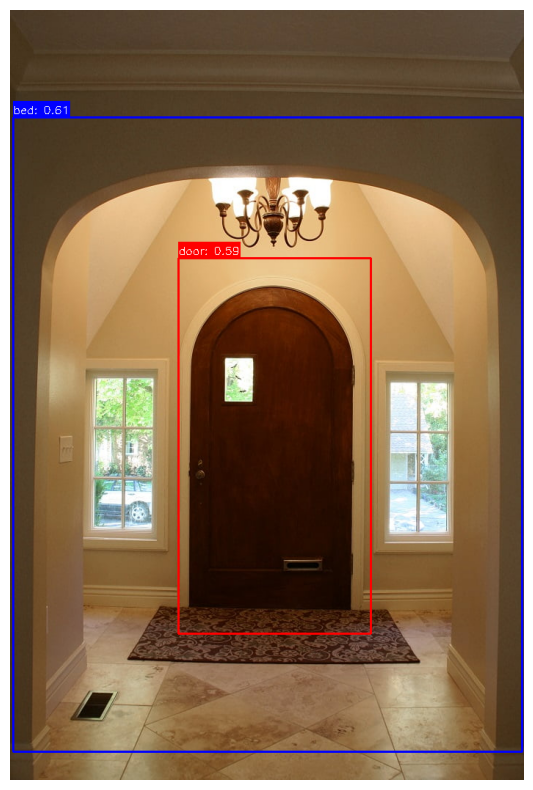

Memory Usage: 711.33 MB


In [16]:
import openvino as ov
import cv2
import numpy as np
import matplotlib.pyplot as plt
import psutil
import os

# --- CONFIG ---
MODEL_PATH = "optimized_int8.xml"    # Path to your OpenVINO INT8 model
IMAGE_PATH = "door2.jpg"           # Path to test image
OUTPUT_PATH = "detections_ov.jpg"  # Where to save annotated image
# ----------------

# Your custom class names
CLASS_NAMES = ['bed', 'chair', 'door', 'door-frame', 'shower', 'sink', 'sofa', 'stairs', 'table', 'toilet']

# Colors for bounding boxes (BGR)
COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), 
          (0, 255, 255), (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0)]

# Get current process info
process = psutil.Process(os.getpid())

# Print memory usage in MB
print(f"Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")

# Load OpenVINO model
print("Loading OpenVINO model...")
core = ov.Core()
model = core.read_model(MODEL_PATH)
compiled_model = core.compile_model(model, "CPU")

# Get model input/output info
input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)
input_name = input_layer.any_name

print(f"Model loaded: {MODEL_PATH}")
print(f"Input shape: {input_layer.shape}")
print(f"Output shape: {output_layer.shape}")

def preprocess_image(image_path):
    """Preprocess image for YOLOv8"""
    image = cv2.imread(image_path)
    original_height, original_width = image.shape[:2]
    
    # Resize to 640x640 with padding
    scale = min(640 / original_width, 640 / original_height)
    new_width, new_height = int(original_width * scale), int(original_height * scale)
    resized = cv2.resize(image, (new_width, new_height))
    
    # Pad to 640x640
    pad_w, pad_h = (640 - new_width) // 2, (640 - new_height) // 2
    padded = np.pad(resized, ((pad_h, 640 - new_height - pad_h),
                             (pad_w, 640 - new_width - pad_w), (0, 0)), 
                   mode='constant', constant_values=114)
    
    # Normalize and format for model
    normalized = padded.astype(np.float32) / 255.0
    transposed = np.transpose(normalized, (2, 0, 1))  # HWC to CHW
    batched = np.expand_dims(transposed, axis=0)  # Add batch dimension
    
    return image, batched, scale, (pad_w, pad_h)

def postprocess_detections(outputs, original_image, scale, pad):
    """Convert model outputs to detections"""
    pad_w, pad_h = pad
    original_height, original_width = original_image.shape[:2]
    
    # Remove batch dimension and transpose if needed
    outputs = outputs[0]
    if outputs.shape[0] < outputs.shape[1]:
        outputs = outputs.T
    
    detections = []
    
    for detection in outputs:
        if len(detection) >= 4:
            x_center, y_center, width, height = detection[:4]
            
            # Get class scores
            if len(detection) > 4:
                class_scores = detection[4:4+len(CLASS_NAMES)]
                class_id = np.argmax(class_scores)
                confidence = class_scores[class_id]
                
                # Filter by confidence
                if confidence >= 0.25:
                    # Convert to corner coordinates
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                    x2 = x_center + width / 2
                    y2 = y_center + height / 2
                    
                    # Scale back to original image
                    x1 = (x1 - pad_w) / scale
                    y1 = (y1 - pad_h) / scale
                    x2 = (x2 - pad_w) / scale
                    y2 = (y2 - pad_h) / scale
                    
                    # Clip to image bounds
                    x1 = max(0, min(x1, original_width))
                    y1 = max(0, min(y1, original_height))
                    x2 = max(0, min(x2, original_width))
                    y2 = max(0, min(y2, original_height))
                    
                    if x2 > x1 and y2 > y1:  # Valid box
                        detections.append({
                            'bbox': [x1, y1, x2, y2],
                            'confidence': confidence,
                            'class_id': class_id,
                            'class_name': CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f'class_{class_id}'
                        })
    
    # Simple NMS
    if len(detections) > 1:
        boxes = [[d['bbox'][0], d['bbox'][1], d['bbox'][2] - d['bbox'][0], d['bbox'][3] - d['bbox'][1]] for d in detections]
        scores = [d['confidence'] for d in detections]
        indices = cv2.dnn.NMSBoxes(boxes, scores, 0.25, 0.45)
        if len(indices) > 0:
            detections = [detections[i] for i in indices.flatten()]
    
    return detections

def draw_detections(image, detections):
    """Draw bounding boxes on image"""
    annotated = image.copy()
    
    for detection in detections:
        x1, y1, x2, y2 = map(int, detection['bbox'])
        confidence = detection['confidence']
        class_name = detection['class_name']
        class_id = detection['class_id']
        
        # Get color
        color = COLORS[class_id % len(COLORS)]
        
        # Draw box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        
        # Draw label
        label = f"{class_name}: {confidence:.2f}"
        (label_width, label_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, y1 - label_height - 10), (x1 + label_width, y1), color, -1)
        cv2.putText(annotated, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    return annotated

# Run inference
original_image, preprocessed, scale, pad = preprocess_image(IMAGE_PATH)

# Predict
outputs = compiled_model({input_name: preprocessed})
output_data = outputs[output_layer]

# Get detections
detections = postprocess_detections(output_data, original_image, scale, pad)

# Process and print detections (same format as original)
if len(detections) == 0:
    print("No objects detected.")
else:
    for detection in detections:
        cls_id = detection['class_id']
        conf = detection['confidence']
        xyxy = detection['bbox']  # [x1, y1, x2, y2]
        class_name = detection['class_name']
        print(f"{class_name}: {conf:.2f}, bbox={xyxy}")

# Annotate image (equivalent to results[0].plot())
annotated = draw_detections(original_image, detections)

# Save annotated image
cv2.imwrite(OUTPUT_PATH, annotated)
print(f"Annotated image saved to {OUTPUT_PATH}")

# Display in notebook (optional)
try:
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.show()
except Exception as e:
    print(f"Could not display image inline: {e}")

# Print memory usage in MB
print(f"Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")

Memory Usage: 1642.16 MB
Loading OpenVINO model...
Model loaded: optimized2_int8.xml
Input shape: [1,3,640,640]
Output shape: [1,14,8400]
bed: 0.61, bbox=[4.386824369430542, 146.01181983947754, 697.576571702957, 1011.2083911895751]
door: 0.59, bbox=[229.72680330276486, 338.89430522918695, 491.57812356948847, 850.1971292495726]
Annotated image saved to detections_ov.jpg


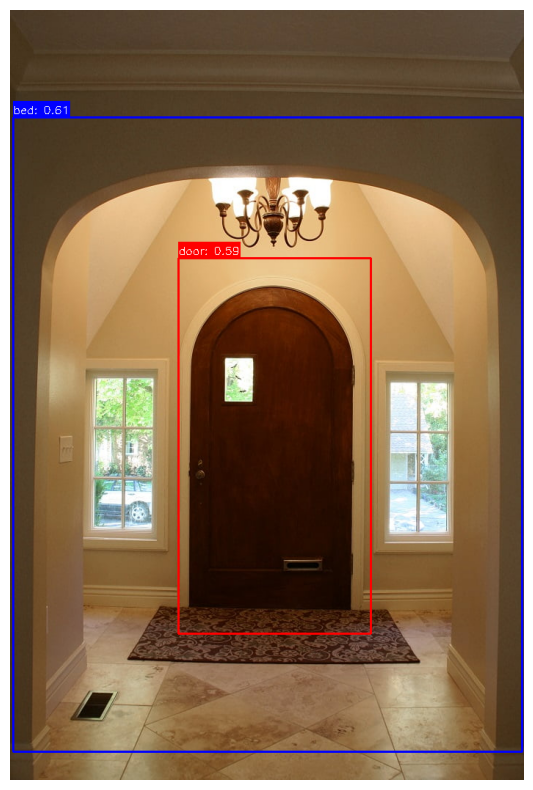

Memory Usage: 1676.85 MB


In [8]:
import openvino as ov
import cv2
import numpy as np
import matplotlib.pyplot as plt
import psutil
import os

# --- CONFIG ---
MODEL_PATH = "optimized2_int8.xml"    # Path to your OpenVINO INT8 model
IMAGE_PATH = "door2.jpg"           # Path to test image
OUTPUT_PATH = "detections_ov.jpg"  # Where to save annotated image
# ----------------

# Your custom class names
CLASS_NAMES = ['bed', 'chair', 'door', 'door-frame', 'shower', 'sink', 'sofa', 'stairs', 'table', 'toilet']

# Colors for bounding boxes (BGR)
COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), 
          (0, 255, 255), (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0)]

# Get current process info
process = psutil.Process(os.getpid())

# Print memory usage in MB
print(f"Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")

# Load OpenVINO model
print("Loading OpenVINO model...")
core = ov.Core()
model = core.read_model(MODEL_PATH)
compiled_model = core.compile_model(model, "CPU")

# Get model input/output info
input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)
input_name = input_layer.any_name

print(f"Model loaded: {MODEL_PATH}")
print(f"Input shape: {input_layer.shape}")
print(f"Output shape: {output_layer.shape}")

def preprocess_image(image_path):
    """Preprocess image for YOLOv8"""
    image = cv2.imread(image_path)
    original_height, original_width = image.shape[:2]
    
    # Resize to 640x640 with padding
    scale = min(640 / original_width, 640 / original_height)
    new_width, new_height = int(original_width * scale), int(original_height * scale)
    resized = cv2.resize(image, (new_width, new_height))
    
    # Pad to 640x640
    pad_w, pad_h = (640 - new_width) // 2, (640 - new_height) // 2
    padded = np.pad(resized, ((pad_h, 640 - new_height - pad_h),
                             (pad_w, 640 - new_width - pad_w), (0, 0)), 
                   mode='constant', constant_values=114)
    
    # Normalize and format for model
    normalized = padded.astype(np.float32) / 255.0
    transposed = np.transpose(normalized, (2, 0, 1))  # HWC to CHW
    batched = np.expand_dims(transposed, axis=0)  # Add batch dimension
    
    return image, batched, scale, (pad_w, pad_h)

def postprocess_detections(outputs, original_image, scale, pad):
    """Convert model outputs to detections"""
    pad_w, pad_h = pad
    original_height, original_width = original_image.shape[:2]
    
    # Remove batch dimension and transpose if needed
    outputs = outputs[0]
    if outputs.shape[0] < outputs.shape[1]:
        outputs = outputs.T
    
    detections = []
    
    for detection in outputs:
        if len(detection) >= 4:
            x_center, y_center, width, height = detection[:4]
            
            # Get class scores
            if len(detection) > 4:
                class_scores = detection[4:4+len(CLASS_NAMES)]
                class_id = np.argmax(class_scores)
                confidence = class_scores[class_id]
                
                # Filter by confidence
                if confidence >= 0.25:
                    # Convert to corner coordinates
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                    x2 = x_center + width / 2
                    y2 = y_center + height / 2
                    
                    # Scale back to original image
                    x1 = (x1 - pad_w) / scale
                    y1 = (y1 - pad_h) / scale
                    x2 = (x2 - pad_w) / scale
                    y2 = (y2 - pad_h) / scale
                    
                    # Clip to image bounds
                    x1 = max(0, min(x1, original_width))
                    y1 = max(0, min(y1, original_height))
                    x2 = max(0, min(x2, original_width))
                    y2 = max(0, min(y2, original_height))
                    
                    if x2 > x1 and y2 > y1:  # Valid box
                        detections.append({
                            'bbox': [x1, y1, x2, y2],
                            'confidence': confidence,
                            'class_id': class_id,
                            'class_name': CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f'class_{class_id}'
                        })
    
    # Simple NMS
    if len(detections) > 1:
        boxes = [[d['bbox'][0], d['bbox'][1], d['bbox'][2] - d['bbox'][0], d['bbox'][3] - d['bbox'][1]] for d in detections]
        scores = [d['confidence'] for d in detections]
        indices = cv2.dnn.NMSBoxes(boxes, scores, 0.25, 0.45)
        if len(indices) > 0:
            detections = [detections[i] for i in indices.flatten()]
    
    return detections

def draw_detections(image, detections):
    """Draw bounding boxes on image"""
    annotated = image.copy()
    
    for detection in detections:
        x1, y1, x2, y2 = map(int, detection['bbox'])
        confidence = detection['confidence']
        class_name = detection['class_name']
        class_id = detection['class_id']
        
        # Get color
        color = COLORS[class_id % len(COLORS)]
        
        # Draw box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        
        # Draw label
        label = f"{class_name}: {confidence:.2f}"
        (label_width, label_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, y1 - label_height - 10), (x1 + label_width, y1), color, -1)
        cv2.putText(annotated, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    return annotated

# Run inference
original_image, preprocessed, scale, pad = preprocess_image(IMAGE_PATH)

# Predict
outputs = compiled_model({input_name: preprocessed})
output_data = outputs[output_layer]

# Get detections
detections = postprocess_detections(output_data, original_image, scale, pad)

# Process and print detections (same format as original)
if len(detections) == 0:
    print("No objects detected.")
else:
    for detection in detections:
        cls_id = detection['class_id']
        conf = detection['confidence']
        xyxy = detection['bbox']  # [x1, y1, x2, y2]
        class_name = detection['class_name']
        print(f"{class_name}: {conf:.2f}, bbox={xyxy}")

# Annotate image (equivalent to results[0].plot())
annotated = draw_detections(original_image, detections)

# Save annotated image
cv2.imwrite(OUTPUT_PATH, annotated)
print(f"Annotated image saved to {OUTPUT_PATH}")

# Display in notebook (optional)
try:
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.show()
except Exception as e:
    print(f"Could not display image inline: {e}")

# Print memory usage in MB
print(f"Memory Usage: {process.memory_info().rss / 1024 ** 2:.2f} MB")

In [6]:
import psutil
import os
import time
import numpy as np
import cv2

from ultralytics import YOLO
from openvino.runtime import Core

# ---------------- CONFIG ----------------
YOLO_PT_PATH = "best.pt"       # YOLOv8 PyTorch weights
YOLO_OV_PATH = "optimized2_int8.xml"      # YOLOv8 OpenVINO IR (FP32 or INT8)
TEST_IMAGE = "door2.jpg"        # A sample image for inference
# ----------------------------------------

process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / (1024 * 1024)

# -------- YOLOv8 PyTorch (CPU) ---------
print("Running YOLOv8 PyTorch on CPU...")
model_pt = YOLO(YOLO_PT_PATH)
model_pt.to("cpu")

img = cv2.imread(TEST_IMAGE)

ram_before = get_ram_mb()
t0 = time.time()
results_pt = model_pt.predict(img, verbose=False)
t1 = time.time()
ram_after = get_ram_mb()

print(f"[YOLOv8 .pt] Inference time: {t1 - t0:.3f}s")
print(f"[YOLOv8 .pt] RAM usage delta: {ram_after - ram_before:.2f} MB")

# -------- YOLOv8 OpenVINO (CPU) --------
print("\nRunning YOLOv8 OpenVINO on CPU...")
core = Core()
ov_model = core.compile_model(YOLO_OV_PATH, "CPU")
input_layer = ov_model.input(0)

# preprocess (same as training)
img_resized = cv2.resize(img, (640, 640))
img_input = np.expand_dims(img_resized.transpose(2, 0, 1), 0).astype(np.float32) / 255.0

ram_before = get_ram_mb()
t0 = time.time()
res = ov_model([img_input])[ov_model.output(0)]
t1 = time.time()
ram_after = get_ram_mb()

print(f"[YOLOv8 OpenVINO] Inference time: {t1 - t0:.3f}s")
print(f"[YOLOv8 OpenVINO] RAM usage delta: {ram_after - ram_before:.2f} MB")


Running YOLOv8 PyTorch on CPU...
[YOLOv8 .pt] Inference time: 0.380s
[YOLOv8 .pt] RAM usage delta: 38.84 MB

Running YOLOv8 OpenVINO on CPU...
[YOLOv8 OpenVINO] Inference time: 0.094s
[YOLOv8 OpenVINO] RAM usage delta: 21.52 MB
